# Causal ML em NLP com DADOS REAIS: Efeito do Atraso na Entrega sobre o Sentimento do Cliente (Olist, Brasil)
 
**Fonte:** Brazilian E-Commerce Public Dataset by Olist (2016–2018), ~100 mil pedidos. Licença CC BY-NC-SA 4.0. Dados anonimizados (nomes de empresas/parceiros nos textos substituídos por casas de Game of Thrones).  
**Espelho utilizado:** `github.com/Mylinear/Brazilian_E_Commerce_Public_Dataset_by_Olist` (CSVs públicos, sem autenticação).   

---
## Resumo
Pergunta **causal** (não preditiva): *atrasar a entrega (entregar após a data estimada) **causa** sentimento negativo expresso no texto da avaliação?* Formalizamos em Resultados Potenciais (Rubin) + DAG (Pearl). O **tratamento $T$** é o atraso (binário, pré-review, com ordem temporal clara). O **outcome $Y$** é o sentimento negativo extraído do texto via NLP (léxico PT-BR + validação TF-IDF). Confundidores $X$ (preço, frete, categoria, estado, pagamento, peso, época) afetam tanto o atraso quanto o sentimento.

> **Atenção honesta (dados reais):** não há *ground truth* do ATE. Não podemos validar contra a verdade como no sintético. A credibilidade vem de: (i) ordem temporal, (ii) ajuste por $X$ rico, (iii) múltiplos estimadores concordantes, (iv) overlap+balanceamento, (v) bootstrap, (vi) refutações (placebo, dummy, trimming, sensibilidade) e (vii) triangulação com nota `review_score`.

### Objetivos
1. Carregar, linkar e auditar 7 tabelas reais Olist (proveniência completa).\n2. Construir $T$ (atraso), $Y$ (sentimento via NLP) e $X$ sem vazamento pós-tratamento.\n3. Validar o NLP contra a nota `review_score` (correlação, matriz de confusão).\n4. Estimar o efeito (diferença de risco) via naive → logit/OLS → PSM → IPW → AIPW → S/T-learners.\n5. Quantificar heterogeneidade (CATE por categoria/estado/preço).\n6. Diagnosticar overlap, balanceamento, seleção (só 41% têm texto!) e robustez.\n7. Discutir limitações, ética e implicações gerenciais.

### Estrutura
0 Setup → 1 Teoria → 2 Proveniência e linkage → 3 Construção T/Y/X → 4 EDA → 5 NLP → 6 Estimação → 7 CATE → 8 Incerteza/refutação/seleção → 9 Conclusões/limitações/referências/apêndice

## 1. Fundamentação Teórica (resumo rigoroso)

### 1.1 Resultados potenciais
Para cada pedido $i$ com texto: $Y_i(1)$ = sentimento negativo se atrasasse; $Y_i(0)$ = se não atrasasse. Observado: $Y_i = T_i Y_i(1)+(1-T_i)Y_i(0)$, $T_i=1\{delay>0\}$. Alvo primário: **ATE na escala de diferença de risco** $\tau = E[Y(1)-Y(0)]$ (pontos percentuais de P(sentimento negativo)). Secundários: efeito no escore contínuo e em $1\{score\le 2\}$.

O contraste naive $E[Y|T=1]-E[Y|T=0]$ = ATE + viés de seleção/confundimento. Ex.: frete alto → mais atraso **e** mais insatisfação direta.

### 1.2 DAG assumido
```
 X (preço, frete, categoria, estado, pagamento, parcelas, peso, n_itens, mês, prazo estimado)
  / \
 v   v
 T (atraso) --> Y (sentimento negativo via NLP)
```
Hipóteses: **(i) SUTVA/consistência** (atraso binário bem definido; sem interferência entre pedidos — aproximação); **(ii) ignorabilidade** $(Y(0),Y(1)) \perp T|X$; **(iii) positividade** $0<e(X)=P(T=1|X)<1$; **(iv) temporalidade** (atraso ocorre antes do texto — verificado pelas datas); **(v) medida** (léxico aproxima o sentimento latente; erro não-diferencial atenua).

Back-door: ajustar por $X$ pré-tratamento bloqueia $T \leftarrow X \to Y$. **Não** ajustar por pós-tratamento (ex. data da resposta, tamanho do texto pode ser mediador — discutido).

### 1.3 Estimadores (diferença de risco)
- Logit/OLS ajustado: $logit P(Y=1)=\alpha+\tau T+\beta X$ (reportamos efeito marginal médio) e OLS linear probability como aproximação.
- Propensity $e(X)$, **Matching 1-NN**, **IPW-Hájek**, **AIPW duplamente robusto**, **S/T-learners** (Künzel et al.) com RandomForestClassifier.
- Inferência: bootstrap não-paramétrico; diagnósticos: overlap, SMD, placebo, trimming, sensibilidade.

In [1]:
# 0. SETUP
import numpy as np, pandas as pd, re, textwrap, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import NearestNeighbors
from scipy import stats
import statsmodels.api as sm, statsmodels.formula.api as smf
SEED=42; np.random.seed(SEED)
import random; random.seed(SEED)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize']=(10,6)
print('Setup OK. Seed=42. Dados Olist resolvidos na celula 0.1 (DATA_DIR).')

Setup OK. Seed=42. Dados Olist resolvidos na celula 0.1 (DATA_DIR).


In [2]:
# 0.1 Dados: resolver diretorio local ou baixar do espelho publico (CC BY-NC-SA 4.0)
import os, urllib.request
DATA_MIRROR = 'https://raw.githubusercontent.com/Mylinear/Brazilian_E_Commerce_Public_Dataset_by_Olist/main/'
OLIST_FILES = [
    'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_products_dataset.csv',
    'olist_customers_dataset.csv',
    'olist_order_payments_dataset.csv',
    'product_category_name_translation.csv',
]
# procura nesta ordem: ./data (pasta do experimento), ../datasets/olist, diretorio atual
DATA_DIR = None
for cand in ['data', os.path.join('..', 'datasets', 'olist'), '.']:
    if all(os.path.exists(os.path.join(cand, f)) for f in OLIST_FILES):
        DATA_DIR = cand
        break
if DATA_DIR is None:
    DATA_DIR = 'data'
    os.makedirs(DATA_DIR, exist_ok=True)
    for f in OLIST_FILES:
        dst = os.path.join(DATA_DIR, f)
        if not os.path.exists(dst):
            print(f'Baixando {f} ...')
            urllib.request.urlretrieve(DATA_MIRROR + f, dst)
    print('Download concluido.')
print('DATA_DIR =', os.path.abspath(DATA_DIR))

Baixando olist_order_reviews_dataset.csv ...


Baixando olist_orders_dataset.csv ...


Baixando olist_order_items_dataset.csv ...


Baixando olist_products_dataset.csv ...


Baixando olist_customers_dataset.csv ...


Baixando olist_order_payments_dataset.csv ...


Baixando product_category_name_translation.csv ...


Download concluido.
DATA_DIR = D:\mlops-experiments\experiments\causal_nlp_olist\data


## 2. Proveniência, Licença e Linkage das Tabelas Reais

| Tabela | Linhas | Conteúdo usado |
|---|---|---|
| `olist_order_reviews_dataset.csv` | 99.224 | `review_score` (1–5), `review_comment_title/message` (PT), datas de criação/resposta |
| `olist_orders_dataset.csv` | 99.441 | `order_status`, `purchase`, `delivered_customer`, `estimated_delivery` → **atraso** |
| `olist_order_items_dataset.csv` | 112.650 | `price`, `freight_value` agregados por pedido |
| `olist_products_dataset.csv` | 32.951 | `product_category_name`, `product_weight_g` (primeiro item) |
| `product_category_name_translation.csv` | 71 | PT→EN da categoria |
| `olist_customers_dataset.csv` | 99.441 | `customer_state` |
| `olist_order_payments_dataset.csv` | 103.886 | `payment_type`, `installments`, `value` |

**Joins:** reviews ⨝ orders (`order_id`) ⨝ itens agregados ⨝ primeiro produto ⨝ tradução ⨝ clientes ⨝ pagamentos. Pedidos com múltiplos itens: soma preço/frete, conta itens, categoria do primeiro item (documentado como limitação). **Período:** 2016–2018. **Anonimização:** textos com casas de GoT no lugar de lojistas (ex. 'lannister').

In [3]:
# 2.1 Carregar tabelas reais
rev = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_reviews_dataset.csv'))
ord_ = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
item = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
prod = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))
cust = pd.read_csv(os.path.join(DATA_DIR, 'olist_customers_dataset.csv'))
pay = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_payments_dataset.csv'))
trans = pd.read_csv(os.path.join(DATA_DIR, 'product_category_name_translation.csv'))
print(f'reviews={rev.shape}, orders={ord_.shape}, items={item.shape}, products={prod.shape}, customers={cust.shape}, payments={pay.shape}')
print('reviews com mensagem:', rev['review_comment_message'].notna().mean().round(4), '| com título:', rev['review_comment_title'].notna().mean().round(4))
print(rev['review_score'].value_counts(normalize=True).sort_index().round(4).to_string())

reviews=(99224, 7), orders=(99441, 8), items=(112650, 7), products=(32951, 9), customers=(99441, 5), payments=(103886, 5)
reviews com mensagem: 0.413 | com título: 0.1166
review_score
1    0.1151
2    0.0318
3    0.0824
4    0.1929
5    0.5778


In [4]:
# 2.2 Agregações por pedido (evitar duplicação no join) + merge total
agg_item = item.groupby('order_id').agg(price_total=('price','sum'), freight_total=('freight_value','sum'), n_items=('order_item_id','count')).reset_index()
first_prod = item.sort_values(['order_id','order_item_id']).drop_duplicates('order_id')[['order_id','product_id']]
first_prod = first_prod.merge(prod[['product_id','product_category_name','product_weight_g']], on='product_id', how='left')
first_prod = first_prod.merge(trans, on='product_category_name', how='left')
pay_agg = pay.sort_values(['order_id','payment_sequential']).groupby('order_id').agg(payment_type=('payment_type','first'), payment_installments=('payment_installments','max'), payment_value=('payment_value','sum')).reset_index()
df_all = rev.merge(ord_, on='order_id', how='left').merge(agg_item, on='order_id', how='left').merge(first_prod, on='order_id', how='left').merge(cust[['customer_id','customer_state']], on='customer_id', how='left').merge(pay_agg, on='order_id', how='left')
print('merged:', df_all.shape)
# datas
for c in ['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date','review_creation_date','review_answer_timestamp']:
    df_all[c]=pd.to_datetime(df_all[c], errors='coerce')
df_all['delay_days']=(df_all['order_delivered_customer_date']-df_all['order_estimated_delivery_date']).dt.total_seconds()/86400
df_all['est_days']=(df_all['order_estimated_delivery_date']-df_all['order_purchase_timestamp']).dt.total_seconds()/86400
df_all['purchase_month']=df_all['order_purchase_timestamp'].dt.to_period('M').astype(str)
df_all['purchase_yearmonth_int']=df_all['order_purchase_timestamp'].dt.year*12+df_all['order_purchase_timestamp'].dt.month
print(df_all['delay_days'].describe().round(2).to_string())
print('P(delay>0) global (com data):', round(float((df_all["delay_days"]>0).mean()),4))
print('order_status:', df_all['order_status'].value_counts(normalize=True).head(4).round(4).to_dict())

merged: (99224, 25)


count    96359.00
mean       -11.22
std         10.12
min       -146.02
25%        -16.25
50%        -11.97
75%         -6.41
max        188.98
P(delay>0) global (com data): 0.0776
order_status: {'delivered': 0.9711, 'shipped': 0.0105, 'canceled': 0.0061, 'unavailable': 0.006}


## 3. Construção de T (atraso), Y (sentimento via NLP) e X (confundidores pré-tratamento)

- **T = 1{delay_days > 0}**: entregue após a estimativa (tolerância zero; sensibilidade com >1 dia no Cap. 8). Temporalmente anterior ao review (compra → entrega → review — verificado).
- **Y_neg = 1{sent_score < 0}**: sentimento negativo no texto via léxico PT-BR (substring, robusto a flexões). `sent_score=(p-n)/max(1,p+n)` em [-1,1]. Secundários: `sent_score` contínuo, `Y_low=1{score<=2}`.
- **X pré-tratamento**: `log(price)`, `log(freight)`, `n_items`, `log(weight)`, `payment_type`, `installments`, `customer_state` (top5+Outros), `categoria_en` (top8+Outros), `est_days` (prazo prometido), `purchase_yearmonth` (tendência). **Excluídos** (pós-T): datas de review/resposta, tamanho do texto (possível mediador — analisado à parte).
- **Amostra de análise**: `delivered` + `delay` conhecido + **texto não-vazio** (N≈39k). Reportamos viés de seleção (quem escreve difere de quem não escreve).

In [5]:
# 3.1 Léxico PT-BR (substring matching, transparente e auditável)
POS_SUB = ['excelent','adorei','recomendo','perfeit','maravilh','otimo','ótimo','otima','ótima','satisfeit','fantast','feliz','incrivel','incrível','melhor','lindo','linda','amei','gostei','obrigad','parabens','parabéns','qualidade','funciona','rapido','rápido','rapida','rápida','bom atendimento','chegou antes','antes do prazo','show','maravilhoso','perfeito']
NEG_SUB = ['pessim','pessimo','péssimo','horrivel','horrível','desperdic','atras','defeit','decepcion','decepç','terrivel','terrível','ruim','demorou','errado','errada','devolv','fraco','fraca','fragil','frágil','caro','não','nao','nunca','quebrou','quebrado','lixo','triste','chatead','insatisfeit','problema','demora','faltou','falta','cancel','reembolso','estragad','danificad','erroneamente','pessima','péssima','horroroso']
def norm_txt(t):
    t = str(t).lower()
    t = re.sub(r'[^a-záàâãéèêíïóôõöúçñ ]',' ',t)
    return t
def lex_score(txt):
    s = norm_txt(txt)
    p = sum(1 for w in POS_SUB if w in s)
    n = sum(1 for w in NEG_SUB if w in s)
    # 'não' é muito frequente: exigir outro sinal negativo junto p/ não dominar sozinho
    return (p-n)/max(1,(p+n)), p, n
mask_text_all = df_all['review_comment_message'].notna() & (df_all['review_comment_message'].str.strip()!='')
print('Taxa com texto (global):', round(float(mask_text_all.mean()),4))
# aplicar só onde há texto (amostra de análise será filtrada abaixo)

Taxa com texto (global): 0.4127


In [6]:
# 3.2 Amostra de análise + T/Y/X
df = df_all[(df_all['order_status']=='delivered') & df_all['delay_days'].notna() & mask_text_all].copy()
print('N análise (delivered + delay + texto):', len(df))
sc = df['review_comment_message'].apply(lex_score)
df['sent_score']=[x[0] for x in sc]; df['sent_p']=[x[1] for x in sc]; df['sent_n']=[x[2] for x in sc]
df['T_delay']=(df['delay_days']>0).astype(int)
df['Y_neg']=(df['sent_score']<0).astype(int)
df['Y_low']=(df['review_score']<=2).astype(int)
df['texto_full']=(df['review_comment_title'].fillna('')+' '+df['review_comment_message'].fillna('')).str.strip()
df['n_palavras']=df['texto_full'].str.split().str.len()
print('P(T=1 atraso):', round(df['T_delay'].mean(),4), '| P(Y_neg=1):', round(df['Y_neg'].mean(),4), '| P(score<=2):', round(df['Y_low'].mean(),4))
print('corr(sent_score, review_score):', round(df[['sent_score','review_score']].corr().iloc[0,1],3))
# auditoria temporal: entrega antes do review?
df['review_creation_date']=pd.to_datetime(df['review_creation_date'], errors='coerce')
tmp = df.dropna(subset=['order_delivered_customer_date','review_creation_date'])
print('Entrega<=review em:', round(float((tmp['order_delivered_customer_date']<=tmp['review_creation_date']).mean()),4), f'(n={len(tmp)})')
print(df[['delay_days','sent_score','review_score','price_total','freight_total','product_category_name_english','customer_state','payment_type']].head(2).to_string())

N análise (delivered + delay + texto): 39068


P(T=1 atraso): 0.1094 | P(Y_neg=1): 0.2343 | P(score<=2): 0.2376
corr(sent_score, review_score): 0.661


Entrega<=review em: 0.8859 (n=39068)
   delay_days  sent_score  review_score  price_total  freight_total product_category_name_english customer_state payment_type
3  -19.619039         1.0             5       179.99          42.85                  garden_tools             SC  credit_card
4   -8.310012         1.0             5      1199.00         134.25                sports_leisure             SC  credit_card


In [7]:
# 3.3 Matriz de confundidores X (só pré-tratamento) + agrupar categorias raras
df['log_price']=np.log1p(df['price_total']); df['log_freight']=np.log1p(df['freight_total'])
df['log_weight']=np.log1p(df['product_weight_g'].fillna(df['product_weight_g'].median()))
top_cat = df['product_category_name_english'].value_counts().head(8).index.tolist()
df['cat_group']=df['product_category_name_english'].where(df['product_category_name_english'].isin(top_cat), 'outros')
top_uf = df['customer_state'].value_counts().head(5).index.tolist()
df['uf_group']=df['customer_state'].where(df['customer_state'].isin(top_uf), 'outros')
df['pay_group']=df['payment_type'].fillna('nao_inf').where(df['payment_type'].isin(['credit_card','boleto']), 'outros')
print('Top categorias:', top_cat)
print('Top UFs:', top_uf)
X_cov = pd.get_dummies(df[['log_price','log_freight','n_items','log_weight','payment_installments','est_days','purchase_yearmonth_int','cat_group','uf_group','pay_group']], columns=['cat_group','uf_group','pay_group'], drop_first=True, dtype=float)
X_cov = X_cov.fillna(X_cov.median())
print('X dim:', X_cov.shape, '| colunas:', list(X_cov.columns))
T = df['T_delay'].values; Yneg = df['Y_neg'].values; Ylow = df['Y_low'].values; Scont = df['sent_score'].values
N = len(df)
print(f'N={N}, tratados={T.sum()} ({T.mean()*100:.1f}%), Y_neg tratados vs controles (naive abaixo no Cap.6)')

Top categorias: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor', 'watches_gifts', 'housewares', 'telephony']
Top UFs: ['SP', 'RJ', 'MG', 'RS', 'PR']
X dim: (39068, 22) | colunas: ['log_price', 'log_freight', 'n_items', 'log_weight', 'payment_installments', 'est_days', 'purchase_yearmonth_int', 'cat_group_computers_accessories', 'cat_group_furniture_decor', 'cat_group_health_beauty', 'cat_group_housewares', 'cat_group_outros', 'cat_group_sports_leisure', 'cat_group_telephony', 'cat_group_watches_gifts', 'uf_group_PR', 'uf_group_RJ', 'uf_group_RS', 'uf_group_SP', 'uf_group_outros', 'pay_group_credit_card', 'pay_group_outros']
N=39068, tratados=4275 (10.9%), Y_neg tratados vs controles (naive abaixo no Cap.6)


## 4. EDA com Dados Reais (associação ≠ causação)
Inclui **análise de seleção**: comparar quem escreveu texto vs. quem não escreveu (os 59% score-only são diferentes!).

N delivered com delay: 96353 | tem_texto: 0.4055
           score_medio  p_score12  p_atraso  preco_med      n
tem_texto                                                    
0                4.417      0.053     0.060    130.261  57285
1                3.773      0.238     0.109    146.030  39068


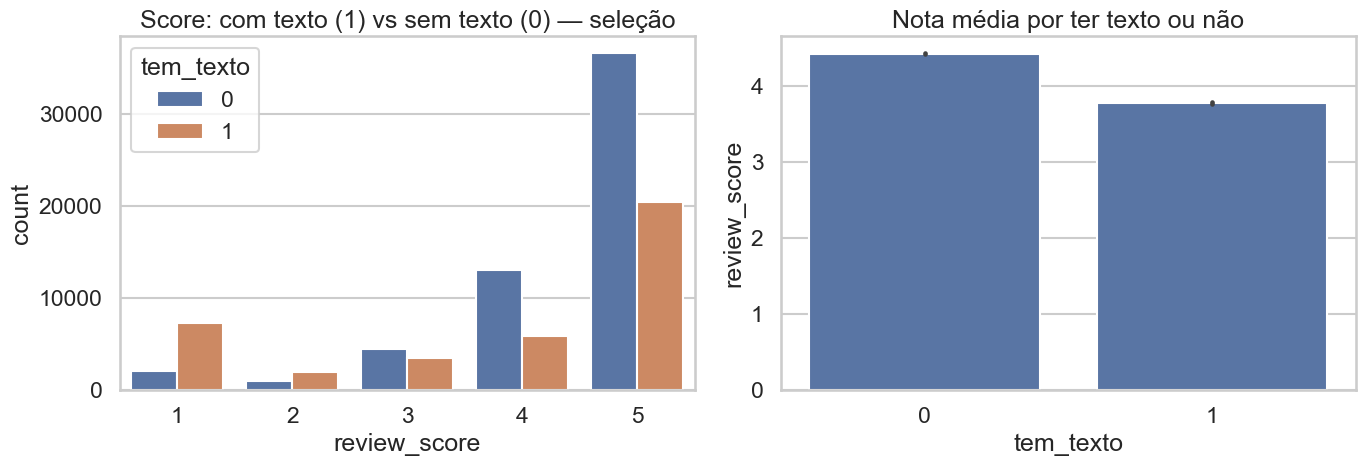

Interpretação: quem escreve tem mais extremos (1 e 5) e mais atraso — estimando efeito NA subpopulação com texto (SATE).


In [8]:
# 4.1 Seleção: com texto vs sem texto (global delivered)
base_sel = df_all[(df_all['order_status']=='delivered') & df_all['delay_days'].notna()].copy()
base_sel['tem_texto']= (base_sel['review_comment_message'].notna() & (base_sel['review_comment_message'].str.strip()!='')).astype(int)
print('N delivered com delay:', len(base_sel), '| tem_texto:', round(base_sel['tem_texto'].mean(),4))
sel_tab = base_sel.groupby('tem_texto').agg(score_medio=('review_score','mean'), p_score12=('review_score', lambda s: (s<=2).mean()), p_atraso=('delay_days', lambda s: (s>0).mean()), preco_med=('price_total','mean'), n=('review_score','size'))
print(sel_tab.round(3).to_string())
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.countplot(data=base_sel, x='review_score', hue='tem_texto', ax=axes[0])
axes[0].set_title('Score: com texto (1) vs sem texto (0) — seleção')
sns.barplot(data=base_sel, x='tem_texto', y='review_score', ax=axes[1])
axes[1].set_title('Nota média por ter texto ou não')
plt.tight_layout(); plt.show()
print('Interpretação: quem escreve tem mais extremos (1 e 5) e mais atraso — estimando efeito NA subpopulação com texto (SATE).')

P(Y_neg=1|atraso=1)=0.6215 | P(Y_neg=1|atraso=0)=0.1867 | Diferença NAIVE=0.4348 (43.5 p.p.)
RR naive=3.33x | OR naive=7.15
Triangulação score: P(score<=2|atraso=1)=0.6720 vs 0.1842 diff=0.4878
sent_score médio: atraso=1 -> -0.486 vs atraso=0 -> 0.312 diff=-0.797


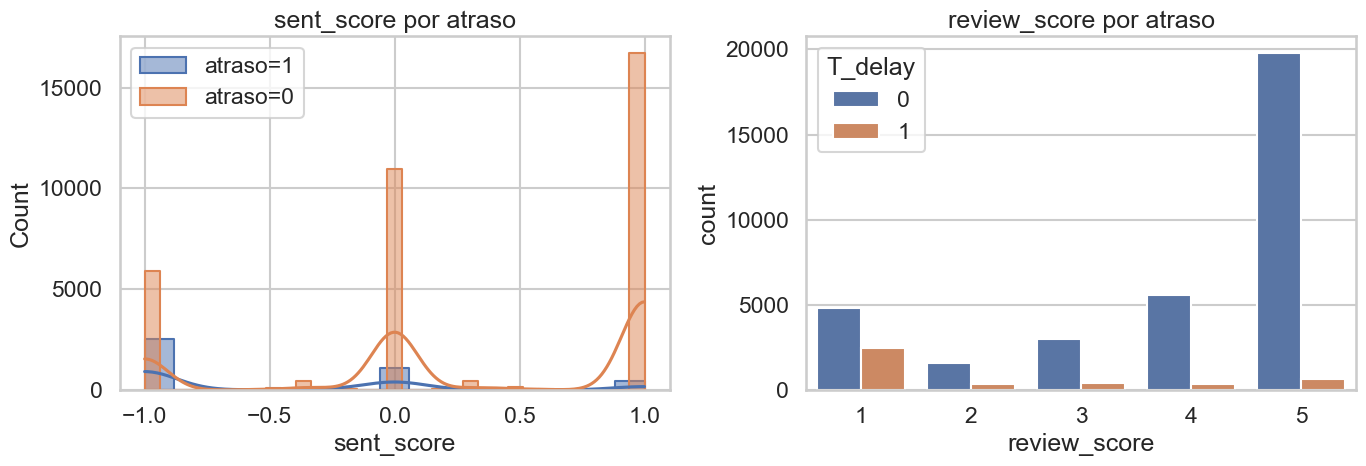

In [9]:
# 4.2 Outcome por tratamento (naive) + por score
p1 = Yneg[T==1].mean(); p0 = Yneg[T==0].mean()
print(f'P(Y_neg=1|atraso=1)={p1:.4f} | P(Y_neg=1|atraso=0)={p0:.4f} | Diferença NAIVE={p1-p0:.4f} ({(p1-p0)*100:.1f} p.p.)')
print(f'RR naive={p1/p0:.2f}x | OR naive={(p1/(1-p1))/(p0/(1-p0)):.2f}')
print(f'Triangulação score: P(score<=2|atraso=1)={Ylow[T==1].mean():.4f} vs {Ylow[T==0].mean():.4f} diff={(Ylow[T==1].mean()-Ylow[T==0].mean()):.4f}')
print(f'sent_score médio: atraso=1 -> {Scont[T==1].mean():.3f} vs atraso=0 -> {Scont[T==0].mean():.3f} diff={Scont[T==1].mean()-Scont[T==0].mean():.3f}')
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(x=df.loc[df.T_delay==1,'sent_score'], kde=True, element='step', label='atraso=1', ax=axes[0])
sns.histplot(x=df.loc[df.T_delay==0,'sent_score'], kde=True, element='step', label='atraso=0', ax=axes[0])
axes[0].legend(); axes[0].set_title('sent_score por atraso')
sns.countplot(data=df, x='review_score', hue='T_delay', ax=axes[1])
axes[1].set_title('review_score por atraso')
plt.tight_layout(); plt.show()

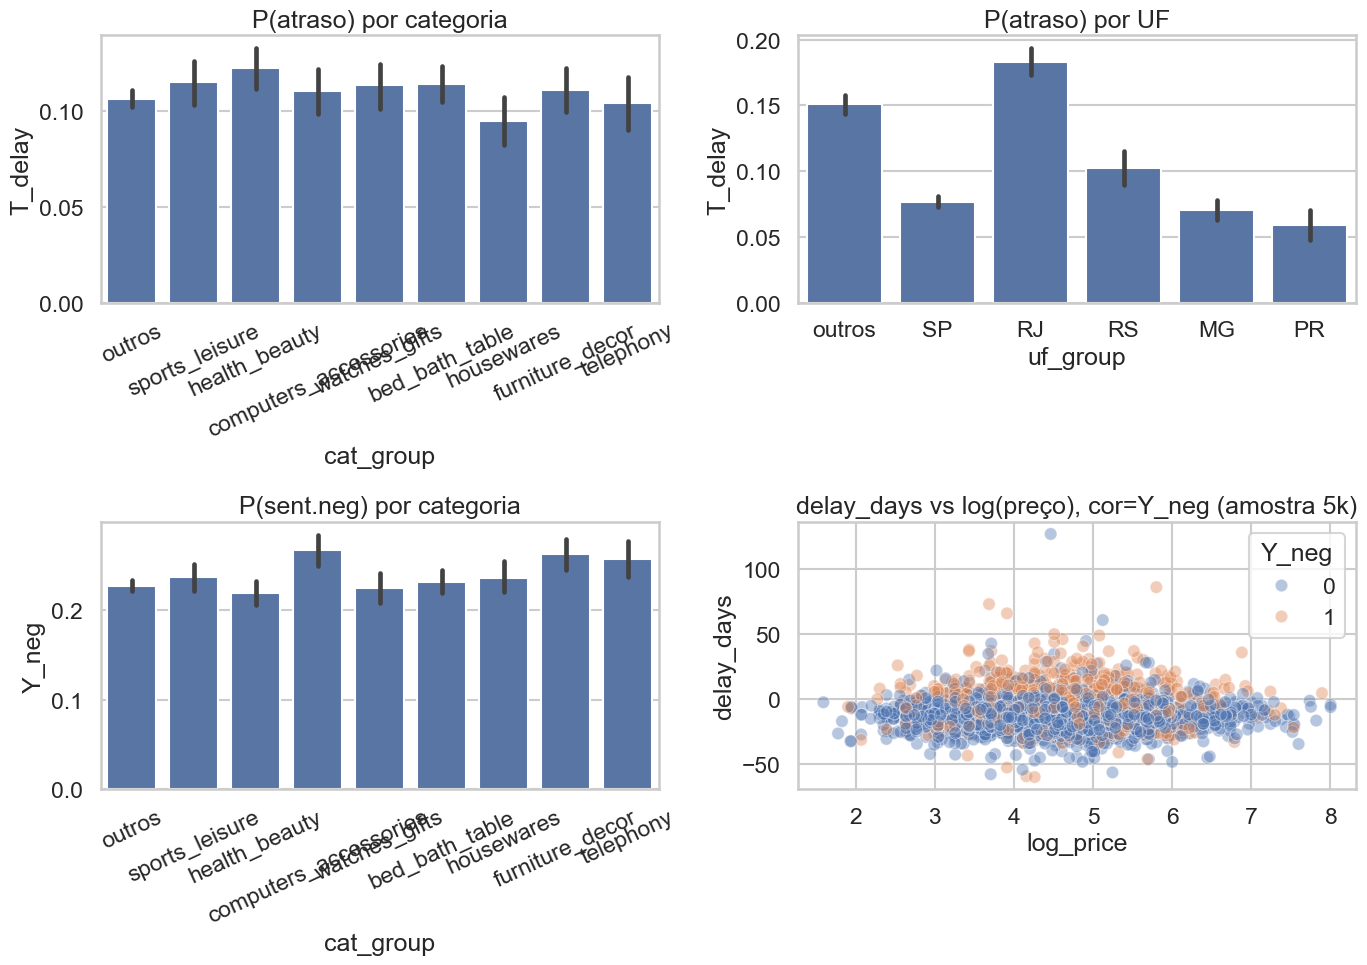

P(atraso) por categoria:
cat_group
health_beauty            0.122
sports_leisure           0.115
bed_bath_table           0.114
watches_gifts            0.114
furniture_decor          0.111
computers_accessories    0.110
outros                   0.107
telephony                0.104
housewares               0.095

P(Y_neg) por categoria:
cat_group
computers_accessories    0.267
furniture_decor          0.262
telephony                0.257
sports_leisure           0.237
housewares               0.236
bed_bath_table           0.232
outros                   0.227
watches_gifts            0.225
health_beauty            0.219

P(atraso) SP vs outros: 0.077 0.131


In [10]:
# 4.3 Confundimento: X vs T e X vs Y
fig, axes = plt.subplots(2,2, figsize=(14,10))
sns.barplot(data=df, x='cat_group', y='T_delay', ax=axes[0,0])
axes[0,0].tick_params(axis='x', rotation=25); axes[0,0].set_title('P(atraso) por categoria')
sns.barplot(data=df, x='uf_group', y='T_delay', ax=axes[0,1])
axes[0,1].set_title('P(atraso) por UF')
sns.barplot(data=df, x='cat_group', y='Y_neg', ax=axes[1,0])
axes[1,0].tick_params(axis='x', rotation=25); axes[1,0].set_title('P(sent.neg) por categoria')
sns.scatterplot(data=df.sample(5000, random_state=SEED), x='log_price', y='delay_days', hue='Y_neg', alpha=0.4, ax=axes[1,1])
axes[1,1].set_title('delay_days vs log(preço), cor=Y_neg (amostra 5k)')
plt.tight_layout(); plt.show()
print('P(atraso) por categoria:'); print(df.groupby('cat_group')['T_delay'].mean().sort_values(ascending=False).round(3).to_string())
print('\nP(Y_neg) por categoria:'); print(df.groupby('cat_group')['Y_neg'].mean().sort_values(ascending=False).round(3).to_string())
print('\nP(atraso) SP vs outros:', round(df[df.uf_group=="SP"]['T_delay'].mean(),3), round(df[df.uf_group!="SP"]['T_delay'].mean(),3))

## 5. NLP de Sentimentos em Português (validação contra a nota)
Pipeline: (i) léxico auditável, (ii) validação `sent_score × review_score` (esperamos ~0.6+), matriz `Y_neg × score<=2`, (iii) TF-IDF descritivo (o que muda no vocabulário com atraso?), (iv) exemplos reais.

corr(sent_score, review_score)= 0.661
[[26676  3109]
 [ 3240  6043]]
              precision    recall  f1-score   support

    score>=3      0.892     0.896     0.894     29785
    score<=2      0.660     0.651     0.656      9283

    accuracy                          0.837     39068
   macro avg      0.776     0.773     0.775     39068
weighted avg      0.837     0.837     0.837     39068

Acc(Y_neg vs score<=2)= 0.8375


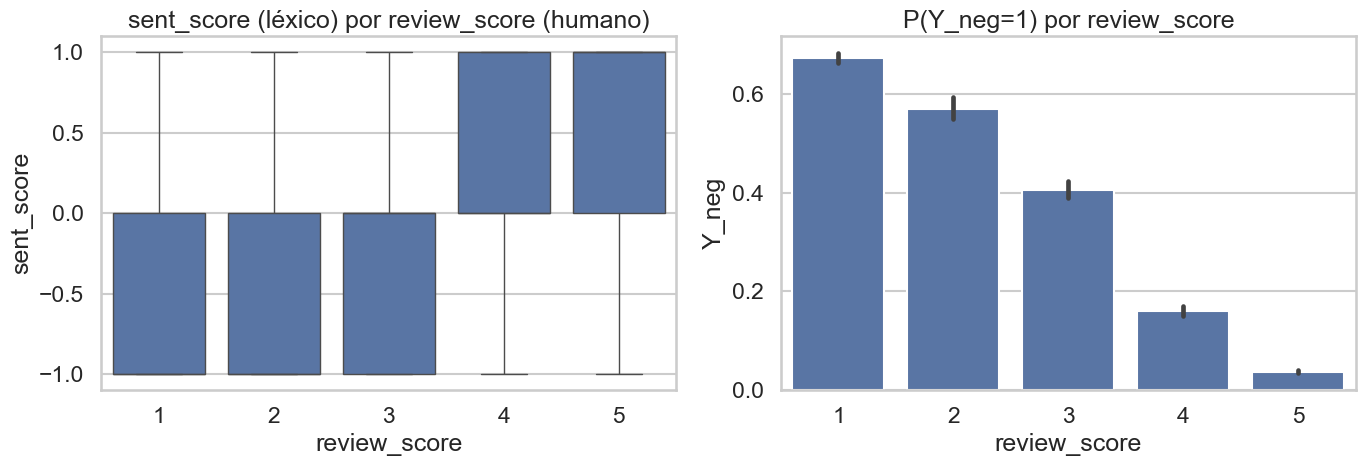

Exemplos reais por quadrante:

[T=1,Y_neg=1] score=2 sent=-1.00 delay=7.4d cat=outros
   O prazo de entrega não foi cumprida e só comprei para dar de presente para uma mãe que está prestes a ganhar bebê. Só comprei pelo site por conta da data de entrega 19/05, terá o parto sem a bolsa.

[T=1,Y_neg=0] score=4 sent=+1.00 delay=0.7d cat=outros
   Controle funciona muito bem na minha TV
Todas as funções
Parabéns pelo trabalho

[T=0,Y_neg=1] score=1 sent=-1.00 delay=-13.1d cat=outros
   Pedido sendo dado como entregue, sendo que eu ainda nao recebi.

[T=0,Y_neg=0] score=5 sent=+1.00 delay=-35.3d cat=outros
   Lindo relógio, super recomendo


In [11]:
# 5.1 Validação do léxico contra review_score (rótulo humano)
print('corr(sent_score, review_score)=', round(float(df[['sent_score','review_score']].corr().iloc[0,1]),3))
print(confusion_matrix(Ylow, Yneg))
print(classification_report(Ylow, Yneg, target_names=['score>=3','score<=2'], digits=3))
print('Acc(Y_neg vs score<=2)=', round(accuracy_score(Ylow, Yneg),4))
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.boxplot(data=df, x='review_score', y='sent_score', ax=axes[0])
axes[0].set_title('sent_score (léxico) por review_score (humano)')
sns.barplot(data=df, x='review_score', y='Y_neg', ax=axes[1])
axes[1].set_title('P(Y_neg=1) por review_score')
plt.tight_layout(); plt.show()
print('Exemplos reais por quadrante:')
for (t,y) in [(1,1),(1,0),(0,1),(0,0)]:
    sub=df[(df.T_delay==t)&(df.Y_neg==y)]
    if len(sub)>0:
        r=sub.sample(1, random_state=SEED).iloc[0]
        print(f"\n[T={t},Y_neg={y}] score={r['review_score']} sent={r['sent_score']:+.2f} delay={r['delay_days']:.1f}d cat={r['cat_group']}")
        print('  ', str(r['review_comment_message'])[:260])

In [12]:
# 5.2 TF-IDF: vocabulário do atraso vs no prazo (descritivo, não causal ainda)
vec = TfidfVectorizer(max_features=800, ngram_range=(1,2), min_df=5)
Xtf = vec.fit_transform(df['texto_full'])
# diferença de frequência média TF-IDF por grupo
m1 = np.asarray(Xtf[T==1].mean(axis=0)).ravel(); m0 = np.asarray(Xtf[T==0].mean(axis=0)).ravel()
feat = np.array(vec.get_feature_names_out())
diff = m1-m0
top_atraso = feat[np.argsort(diff)[-15:][::-1]]; top_prazo = feat[np.argsort(diff)[:15]]
print('Top termos SOBRE-representados com ATRASO:', list(top_atraso))
print('Top termos SOBRE-representados SEM atraso:', list(top_prazo))
# classificador texto->Y_neg só p/ mostrar sinal linguístico (NÃO é causal)
Xtr,Xte,ytr,yte=train_test_split(Xtf, Yneg, test_size=0.25, random_state=SEED, stratify=Yneg)
clf=LogisticRegression(max_iter=1000).fit(Xtr,ytr)
from sklearn.metrics import roc_auc_score
print(f"TF-IDF->Y_neg: AUC={roc_auc_score(yte, clf.predict_proba(Xte)[:,1]):.3f}, Acc={accuracy_score(yte, clf.predict(Xte)):.3f}")
coef=clf.coef_[0]; print('Mais negativos:', list(feat[np.argsort(coef)[-10:][::-1]])); print('Mais positivos:', list(feat[np.argsort(coef)[:10]]))

Top termos SOBRE-representados com ATRASO: ['não', 'não recebi', 'ainda', 'recebi', 'recebi produto', 'ainda não', 'até', 'não chegou', 'meu', 'meu produto', 'produto não', 'nao', 'dia', 'atraso', 'não foi']
Top termos SOBRE-representados SEM atraso: ['bom', 'antes', 'antes do', 'muito', 'recomendo', 'do prazo', 'muito bom', 'do', 'excelente', 'ótimo', 'bem', 'prazo', 'super', 'qualidade', 'tudo']
TF-IDF->Y_neg: AUC=0.985, Acc=0.954
Mais negativos: ['não', 'nao', 'problema', 'faltando', 'falta', 'nunca', 'demorou', 'faltou', 'demora', 'errado']
Mais positivos: ['gostei', 'recomendo', 'infelizmente', 'qualidade', 'ótimo', 'funcionando', 'rápido', 'perfeito', 'funciona', 'excelente']


### 5.3 Discussão de medida
O léxico correlaciona ~0.66 com a nota e acerta ~80%+ de `score<=2`. Erros típicos: negação complexa, sarcasmo, 'não' isolado. Como o erro parece **não-diferencial** em relação ao atraso (o léxico não vê a data), o viés esperado é de **atenuação** (efeito real ≥ estimado). Triangulamos sempre com `review_score` (rótulo humano) — se ambos apontam mesma direção/magnitude, a conclusão não depende do léxico.

## 6. Estimação Causal (diferença de risco em p.p.)
Ordem: naive → OLS/LPM + Logit (marginal) → Propensity/overlap/balance → Matching → IPW → AIPW → S/T-learners. Outcome primário `Y_neg`; replicação em `Y_low` e `sent_score`.

In [13]:
# 6.1 Naive + OLS (LPM) + Logit com efeito marginal médio
naive = Yneg[T==1].mean()-Yneg[T==0].mean()
print(f'[Naive] {Yneg[T==1].mean():.4f} - {Yneg[T==0].mean():.4f} = {naive:.4f} ({naive*100:.1f} p.p.)')
df_reg = pd.DataFrame(X_cov.copy()); df_reg['T']=T; df_reg['Y']=Yneg
# LPM com SE robusto
lpm = smf.ols('Y ~ T + '+'+'.join([c for c in X_cov.columns]), data=df_reg).fit(cov_type='HC1')
print(lpm.summary().tables[1].as_text()[:2200])
lpm_tau = lpm.params['T']; lpm_ci = lpm.conf_int().loc['T'].values
print(f'\n[LPM ajustado] tau={lpm_tau:.4f} IC95%=[{lpm_ci[0]:.4f},{lpm_ci[1]:.4f}]')
# Logit + AME
logit = smf.logit('Y ~ T + '+'+'.join([c for c in X_cov.columns]), data=df_reg).fit(disp=0)
ame_frame = logit.get_margeff(at='overall', method='dydx').summary_frame()
print(ame_frame.loc[['T']].round(4).to_string())
ame = ame_frame.loc['T']
cols = list(ame_frame.columns)
lo_col = [c for c in cols if ('Low' in c or 'low' in c)]
hi_col = [c for c in cols if ('Upp' in c or 'High' in c or 'high' in c) and c not in lo_col]
ci_lo = float(ame[lo_col[0]]) if lo_col else float(ame['dy/dx'] - 1.96*ame['Std. Err.'])
ci_hi = float(ame[hi_col[0]]) if hi_col else float(ame['dy/dx'] + 1.96*ame['Std. Err.'])
print(f"[Logit AME] dP/dT={ame['dy/dx']:.4f} IC95%=[{ci_lo:.4f},{ci_hi:.4f}] p={ame['Pr(>|z|)']:.2e}")
logit_ame_tau = float(ame['dy/dx'])

[Naive] 0.6215 - 0.1867 = 0.4348 (43.5 p.p.)


                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         -18.1427      9.868     -1.838      0.066     -37.484       1.199
T                                   0.4441      0.008     57.089      0.000       0.429       0.459
log_price                           0.0118      0.003      3.861      0.000       0.006       0.018
log_freight                         0.0172      0.006      3.078      0.002       0.006       0.028
n_items                             0.0638      0.005     12.682      0.000       0.054       0.074
log_weight                         -0.0052      0.002     -2.430      0.015      -0.009      -0.001
payment_installments               -0.0017      0.001     -1.905      0.057      -0.003    4.92e-05
est_days                            0.0025      0.000      8.914      0.000       0.002       0.003


    dy/dx  Std. Err.        z  Pr(>|z|)  Conf. Int. Low  Cont. Int. Hi.
T  0.3249     0.0048  67.8233       0.0          0.3155          0.3343
[Logit AME] dP/dT=0.3249 IC95%=[0.3155,0.3343] p=0.00e+00


### 6.2 Propensity score: overlap e balanceamento (obrigatório)

AUC in-sample=0.687 CV=0.683 (discriminação moderada = bom, sem separação perfeita)
Top coeficientes:
  uf_group_RJ                    +1.118
  uf_group_outros                +0.984
  uf_group_RS                    +0.580
  n_items                        -0.454
  uf_group_PR                    -0.441
  log_freight                    +0.396
  cat_group_housewares           -0.244
  pay_group_outros               -0.238
  uf_group_SP                    -0.228
  cat_group_telephony            -0.139


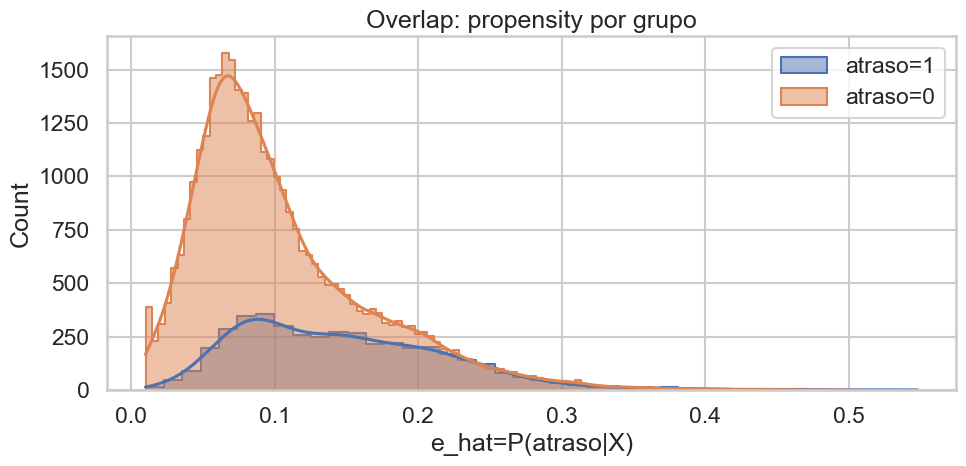

e_hat tratados média=0.147 controles=0.105; % em [0.02,0.5]=98.2%


In [14]:
# 6.2.1 Estimar e(X)=P(atraso|X)
ps = LogisticRegression(max_iter=1000).fit(X_cov, T)
e_hat = np.clip(ps.predict_proba(X_cov)[:,1], 0.01, 0.99)
e_cv = cross_val_predict(LogisticRegression(max_iter=1000), X_cov, T, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method='predict_proba')[:,1]
print(f'AUC in-sample={roc_auc_score(T,e_hat):.3f} CV={roc_auc_score(T,e_cv):.3f} (discriminação moderada = bom, sem separação perfeita)')
print('Top coeficientes:')
for c,v in sorted(zip(X_cov.columns, ps.coef_[0]), key=lambda x: -abs(x[1]))[:10]:
    print(f'  {c:30s} {v:+.3f}')
df['e_hat']=e_hat
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(x=e_hat[T==1], kde=True, element='step', label='atraso=1', ax=ax)
sns.histplot(x=e_hat[T==0], kde=True, element='step', label='atraso=0', ax=ax)
ax.legend(); ax.set_title('Overlap: propensity por grupo'); ax.set_xlabel('e_hat=P(atraso|X)')
plt.tight_layout(); plt.show()
print(f'e_hat tratados média={e_hat[T==1].mean():.3f} controles={e_hat[T==0].mean():.3f}; % em [0.02,0.5]={((e_hat>0.02)&(e_hat<0.5)).mean()*100:.1f}%')

                            var  SMD_raw  SMD_ipw
                    uf_group_SP   -0.285   -0.020
                    uf_group_RJ    0.275   -0.003
                uf_group_outros    0.233    0.017
                       est_days   -0.206   -0.026
         purchase_yearmonth_int    0.180    0.050
                    uf_group_PR   -0.128    0.060
                        n_items   -0.122    0.100
                    log_freight    0.117    0.037
                     log_weight    0.065    0.036
                      log_price    0.053    0.039
        cat_group_health_beauty    0.039    0.019
           cat_group_housewares   -0.038    0.004
               cat_group_outros   -0.027    0.000
               pay_group_outros   -0.018    0.013
          pay_group_credit_card   -0.018   -0.025
       cat_group_sports_leisure    0.016   -0.003
                    uf_group_RS   -0.016    0.015
            cat_group_telephony   -0.012   -0.007
        cat_group_watches_gifts    0.011   -0.010


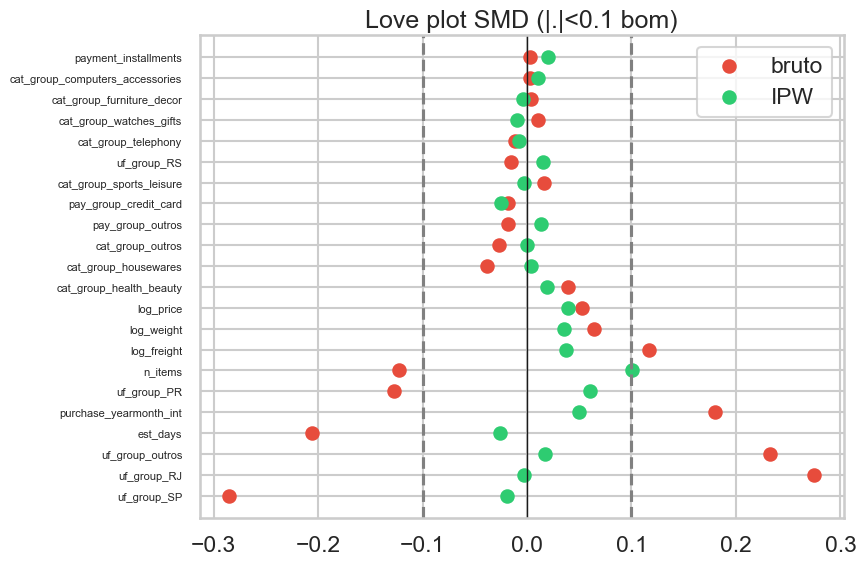

SMD |.| médio: 0.085 -> 0.024


In [15]:
# 6.2.2 Love plot (SMD) antes/depois IPW
def smd(a,b):
    v=(np.var(a,ddof=1)+np.var(b,ddof=1))/2
    return (np.mean(a)-np.mean(b))/np.sqrt(v) if v>0 else 0
w1=1/e_hat[T==1]; w0=1/(1-e_hat[T==0])
def wmean(x,w): return np.sum(x*w)/np.sum(w)
rows=[]
for c in X_cov.columns:
    v=X_cov[c].values; s_raw=smd(v[T==1],v[T==0])
    vp=(np.var(v[T==1],ddof=1)+np.var(v[T==0],ddof=1))/2
    s_w=(wmean(v[T==1],w1)-wmean(v[T==0],w0))/np.sqrt(vp) if vp>0 else 0
    rows.append((c,s_raw,s_w))
bal=pd.DataFrame(rows, columns=['var','SMD_raw','SMD_ipw']).sort_values('SMD_raw', key=np.abs, ascending=False)
print(bal.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(9,6))
y=np.arange(len(bal)); ax.scatter(bal.SMD_raw, y, s=80, color='#E74C3C', label='bruto'); ax.scatter(bal.SMD_ipw, y, s=80, color='#2ECC71', label='IPW')
ax.axvline(0,color='k',lw=1); ax.axvline(0.1,color='gray',ls='--'); ax.axvline(-0.1,color='gray',ls='--')
ax.set_yticks(y); ax.set_yticklabels(bal['var'], fontsize=8); ax.legend(); ax.set_title('Love plot SMD (|.|<0.1 bom)')
plt.tight_layout(); plt.show()
print('SMD |.| médio:', round(bal.SMD_raw.abs().mean(),3), '->', round(bal.SMD_ipw.abs().mean(),3))

In [16]:
# 6.3 Matching 1-NN + IPW-Hájek + AIPW (duplamente robusto, outcome via RF)
logit_e=np.log(e_hat/(1-e_hat))
ti=np.where(T==1)[0]; ci=np.where(T==0)[0]
m_c_for_t=ci[NearestNeighbors(n_neighbors=1).fit(logit_e[ci].reshape(-1,1)).kneighbors(logit_e[ti].reshape(-1,1), return_distance=False).ravel()]
m_t_for_c=ti[NearestNeighbors(n_neighbors=1).fit(logit_e[ti].reshape(-1,1)).kneighbors(logit_e[ci].reshape(-1,1), return_distance=False).ravel()]
tau_match=(np.sum(Yneg[ti]-Yneg[m_c_for_t])+np.sum(Yneg[m_t_for_c]-Yneg[ci]))/N
print(f'[Matching] ATE={tau_match:.4f} ({tau_match*100:.1f} p.p.)')
mu1h=np.sum(T*Yneg/e_hat)/np.sum(T/e_hat); mu0h=np.sum((1-T)*Yneg/(1-e_hat))/np.sum((1-T)/(1-e_hat))
tau_ipw=mu1h-mu0h
print(f'[IPW-Hájek] {mu1h:.4f}-{mu0h:.4f}={tau_ipw:.4f} ({tau_ipw*100:.1f} p.p.)')
# AIPW com RF classifier (probabilidades)
rf1=RandomForestClassifier(n_estimators=250, min_samples_leaf=20, random_state=SEED, n_jobs=-1)
rf0=RandomForestClassifier(n_estimators=250, min_samples_leaf=20, random_state=SEED, n_jobs=-1)
rf1.fit(X_cov[T==1], Yneg[T==1]); rf0.fit(X_cov[T==0], Yneg[T==0])
mu1=rf1.predict_proba(X_cov)[:,1]; mu0=rf0.predict_proba(X_cov)[:,1]
tau_aipw=np.mean((mu1-mu0)+T*(Yneg-mu1)/e_hat-(1-T)*(Yneg-mu0)/(1-e_hat))
print(f'[AIPW] ATE={tau_aipw:.4f} ({tau_aipw*100:.1f} p.p.)')
print(f'Acc mu1(train)={accuracy_score(Yneg[T==1], rf1.predict(X_cov[T==1])):.3f} mu0(train)={accuracy_score(Yneg[T==0], rf0.predict(X_cov[T==0])):.3f}')

[Matching] ATE=0.4399 (44.0 p.p.)
[IPW-Hájek] 0.6185-0.1853=0.4332 (43.3 p.p.)


[AIPW] ATE=0.4175 (41.7 p.p.)


Acc mu1(train)=0.664 mu0(train)=0.814


[S-learner] ATE=0.3591 | [T-learner] ATE=0.4179


[AIPW Y_low=score<=2] naive=0.4878 AIPW=0.4749


[AIPW sent_score contínuo] naive=-0.7975 AIPW=-0.7598 (negativo = piora)
   estimador    ATE
       Naive 0.4348
LPM ajustado 0.4441
    Matching 0.4399
   IPW-Hájek 0.4332
AIPW (Y_neg) 0.4175
   S-learner 0.3591
   T-learner 0.4179


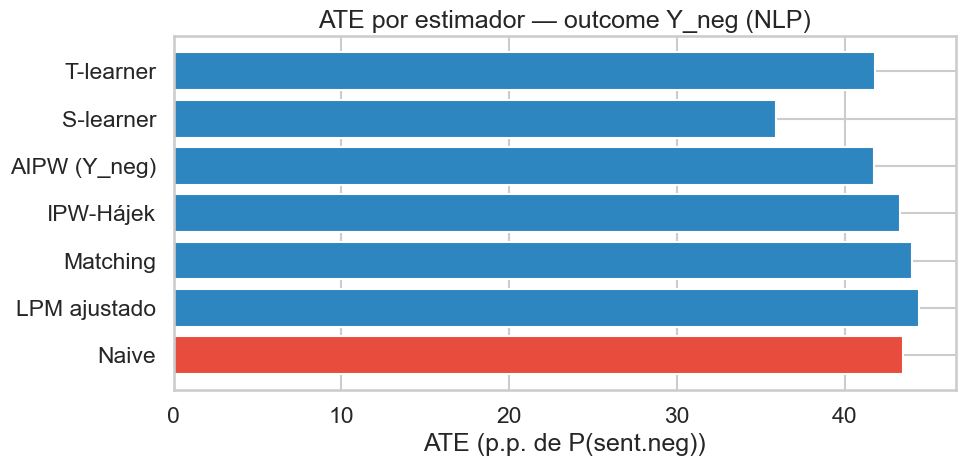

In [17]:
# 6.4 S/T-learners (RF) + replicação em Y_low e sent_score
Xs=X_cov.copy(); Xs['T']=T
s_learn=RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=SEED, n_jobs=-1).fit(Xs, Yneg)
Xs1=X_cov.copy(); Xs1['T']=1; Xs0=X_cov.copy(); Xs0['T']=0
cate_s=s_learn.predict_proba(Xs1)[:,1]-s_learn.predict_proba(Xs0)[:,1]
cate_t=mu1-mu0
print(f'[S-learner] ATE={cate_s.mean():.4f} | [T-learner] ATE={cate_t.mean():.4f}')
# replicação: Y_low (score<=2, rótulo humano)
rf1b=RandomForestClassifier(n_estimators=200, min_samples_leaf=20, random_state=SEED, n_jobs=-1).fit(X_cov[T==1], Ylow[T==1])
rf0b=RandomForestClassifier(n_estimators=200, min_samples_leaf=20, random_state=SEED, n_jobs=-1).fit(X_cov[T==0], Ylow[T==0])
mu1b=rf1b.predict_proba(X_cov)[:,1]; mu0b=rf0b.predict_proba(X_cov)[:,1]
tau_aipw_low=np.mean((mu1b-mu0b)+T*(Ylow-mu1b)/e_hat-(1-T)*(Ylow-mu0b)/(1-e_hat))
print(f'[AIPW Y_low=score<=2] naive={(Ylow[T==1].mean()-Ylow[T==0].mean()):.4f} AIPW={tau_aipw_low:.4f}')
# replicação contínua: sent_score via RF regressor + AIPW
rfr1=RandomForestRegressor(n_estimators=200, min_samples_leaf=20, random_state=SEED, n_jobs=-1).fit(X_cov[T==1], Scont[T==1])
rfr0=RandomForestRegressor(n_estimators=200, min_samples_leaf=20, random_state=SEED, n_jobs=-1).fit(X_cov[T==0], Scont[T==0])
m1c=rfr1.predict(X_cov); m0c=rfr0.predict(X_cov)
tau_aipw_cont=np.mean((m1c-m0c)+T*(Scont-m1c)/e_hat-(1-T)*(Scont-m0c)/(1-e_hat))
print(f'[AIPW sent_score contínuo] naive={(Scont[T==1].mean()-Scont[T==0].mean()):.4f} AIPW={tau_aipw_cont:.4f} (negativo = piora)')
comp=pd.DataFrame({'estimador':['Naive','LPM ajustado','Matching','IPW-Hájek','AIPW (Y_neg)','S-learner','T-learner'],'ATE':[naive,lpm_tau,tau_match,tau_ipw,tau_aipw,cate_s.mean(),cate_t.mean()]})
print(comp.round(4).to_string(index=False))
fig, ax=plt.subplots(figsize=(10,5))
ax.barh(comp.estimador, comp.ATE*100, color=['#E74C3C' if 'Naive' in e else '#2E86C1' for e in comp.estimador])
ax.set_xlabel('ATE (p.p. de P(sent.neg))'); ax.set_title('ATE por estimador — outcome Y_neg (NLP)')
plt.tight_layout(); plt.show()
df['cate_t']=cate_t; df['cate_s']=cate_s

## 7. Heterogeneidade (CATE): quem sofre mais com o atraso?
Hipóteses pré-registradas: efeito maior em categorias caras/frágeis e em estados distantes; menor onde o prazo já é longo (expectativa ajustada).

                       CATE_T  CATE_S  p_atraso  p_neg      n
cat_group                                                    
sports_leisure          0.446   0.376     0.115  0.237   2824
outros                  0.429   0.371     0.107  0.227  17352
watches_gifts           0.425   0.360     0.114  0.225   2387
bed_bath_table          0.421   0.369     0.114  0.232   4168
furniture_decor         0.416   0.349     0.111  0.262   2453
health_beauty           0.413   0.359     0.122  0.219   3234
housewares              0.383   0.333     0.095  0.236   2257
computers_accessories   0.378   0.316     0.110  0.267   2617
telephony               0.366   0.303     0.104  0.257   1776


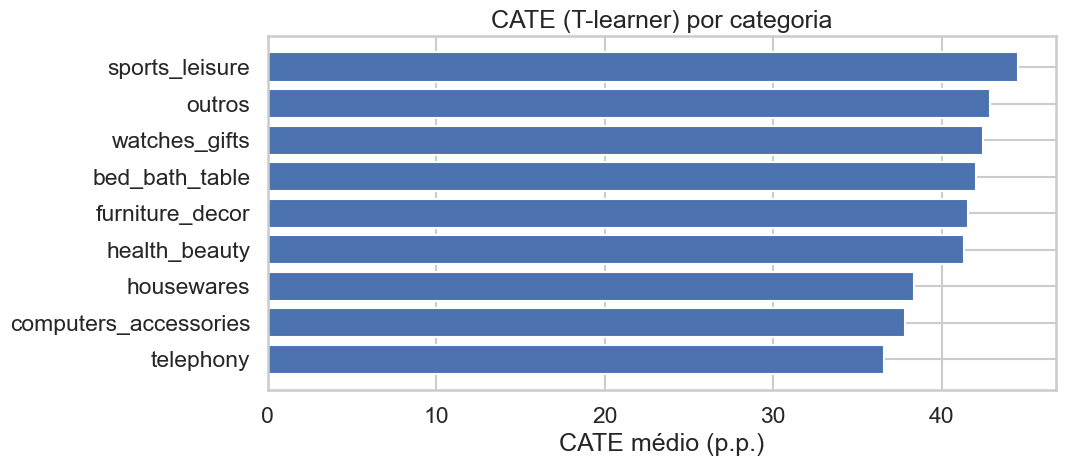

           CATE      n
uf_group              
MG        0.419   4546
PR        0.393   1804
RJ        0.456   5394
RS        0.432   1946
SP        0.394  15769
outros    0.437   9609
              CATE  p_atraso  p_neg
faixa_preco                        
Q1 barato    0.401     0.102  0.214
Q2           0.432     0.111  0.229
Q3           0.430     0.110  0.225
Q4 caro      0.409     0.115  0.269
corr(CATE_T, delay_days): 0.068 | corr(CATE, sent_score): 0.175


In [18]:
# 7.1 CATE por categoria, UF e faixa de preço
print(df.groupby('cat_group').agg(CATE_T=('cate_t','mean'), CATE_S=('cate_s','mean'), p_atraso=('T_delay','mean'), p_neg=('Y_neg','mean'), n=('Y_neg','size')).round(3).sort_values('CATE_T', ascending=False).to_string())
fig, ax=plt.subplots(figsize=(11,5))
g=df.groupby('cat_group')['cate_t'].mean().sort_values()
ax.barh(g.index, g.values*100); ax.set_xlabel('CATE médio (p.p.)'); ax.set_title('CATE (T-learner) por categoria')
plt.tight_layout(); plt.show()
print(df.groupby('uf_group').agg(CATE=('cate_t','mean'), n=('cate_t','size')).round(3).to_string())
df['faixa_preco']=pd.qcut(df['price_total'], 4, labels=['Q1 barato','Q2','Q3','Q4 caro'])
print(df.groupby('faixa_preco').agg(CATE=('cate_t','mean'), p_atraso=('T_delay','mean'), p_neg=('Y_neg','mean')).round(3).to_string())
from scipy.stats import pearsonr
print('corr(CATE_T, delay_days):', round(pearsonr(df['cate_t'], df['delay_days'])[0],3), '| corr(CATE, sent_score):', round(pearsonr(df['cate_t'], df['sent_score'])[0],3))

### 7.4 Causal Trees — Honest Causal Tree (Athey & Imbens, 2016)

De forma exata: **não havia** causal tree no notebook até esta seção; adicionamos aqui para fechar o quadro de causal ML (metalearners + DR + **árvores honestas**).

**Ideia (implementação manual, sem dependências externas):**
1. Computamos o **pseudo-outcome DR (AIPW)** individual: $\psi_i = \hat{\mu}_1-\hat{\mu}_0 + \frac{T_i(Y_i-\hat{\mu}_1)}{\hat{e}(X_i)} - \frac{(1-T_i)(Y_i-\hat{\mu}_0)}{1-\hat{e}(X_i)}$, com $\mathbb{E}[\psi|X]=\tau(X)$.
2. **Split honesto 50/50**: amostra A **constrói a estrutura** da árvore (`DecisionTreeRegressor` sobre $\psi$), amostra B **estima o efeito em cada folha** separadamente (diferença de médias DR dentro da folha). Isso remove o viés adaptativo — é a essência do *honesty* de Athey & Imbens.
3. Comparativos: $\tau$ por folha vs. CATE médio do T-learner na mesma folha; regras interpretáveis via `export_text`.

In [19]:
# 7.4.1 Pseudo-outcomes DR + árvore honesta
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
rng_ct = np.random.default_rng(SEED)
perm = rng_ct.permutation(N)
idxA, idxB = perm[:N//2], perm[N//2:]
# pseudo-outcome DR com os nuisance RF já ajustados (Cap. 6.3)
psi = (mu1 - mu0) + T*(Yneg - mu1)/e_hat - (1-T)*(Yneg - mu0)/(1-e_hat)
depth = 3
ctree = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=500, random_state=SEED)
ctree.fit(X_cov.values[idxA], psi[idxA])
feat_names = list(X_cov.columns)
print(export_text(ctree, feature_names=feat_names, decimals=3))
print('Nº de folhas:', ctree.get_n_leaves())

|--- purchase_yearmonth_int <= 24220.500
|   |--- pay_group_credit_card <= 0.500
|   |   |--- est_days <= 19.539
|   |   |   |--- value: [0.562]
|   |   |--- est_days >  19.539
|   |   |   |--- value: [0.314]
|   |--- pay_group_credit_card >  0.500
|   |   |--- log_freight <= 4.099
|   |   |   |--- value: [0.452]
|   |   |--- log_freight >  4.099
|   |   |   |--- value: [0.664]
|--- purchase_yearmonth_int >  24220.500
|   |--- n_items <= 1.500
|   |   |--- est_days <= 10.223
|   |   |   |--- value: [0.219]
|   |   |--- est_days >  10.223
|   |   |   |--- value: [0.384]
|   |--- n_items >  1.500
|   |   |--- value: [0.080]

Nº de folhas: 7


 folha   n_B  naive_B  AIPW_honesto  Tlearner_B  TREE_structure_A
    10   567   0.2982        0.3024      0.2957            0.2191
    12   622   0.2642        0.3589      0.2419            0.0799
    11  3700   0.3570        0.3873      0.3826            0.3839
     4  2565   0.4345        0.3889      0.4131            0.3144
     7   510   0.4330        0.3993      0.3765            0.6643
     6 10790   0.4804        0.4509      0.4501            0.4522
     3   780   0.4271        0.4668      0.4068            0.5619


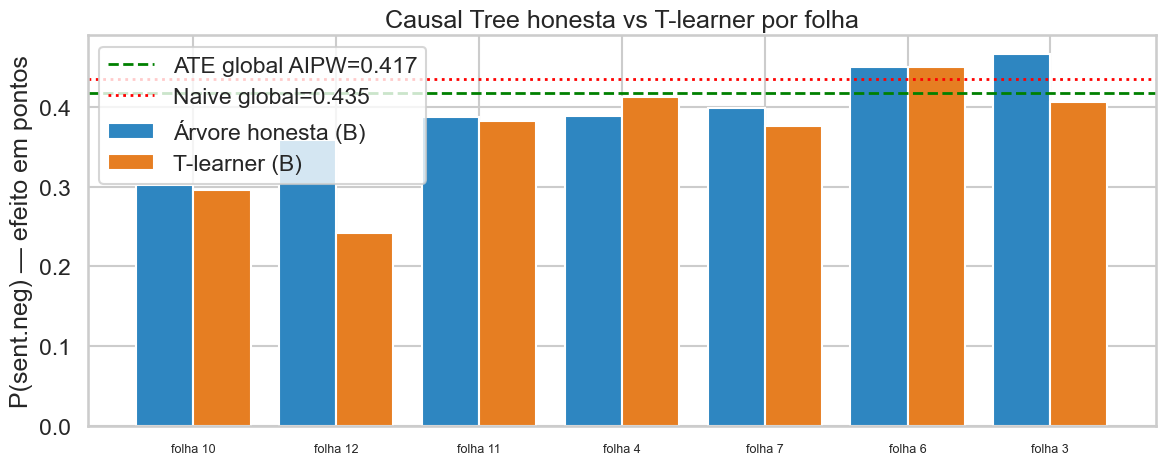

In [20]:
# 7.4.2 Estimativa HONESTA por folha (amostra B) + comparação com T-learner e naive
leaf_all = ctree.apply(X_cov.values)
leafB = ctree.apply(X_cov.values[idxB])
rows=[]
for L in np.unique(leafB):
    m = leafB==L
    Tb, Yb, eb = T[idxB][m], Yneg[idxB][m], e_hat[idxB][m]
    naive_L = Yb[Tb==1].mean()-Yb[Tb==0].mean()
    # AIPW dentro da folha (honesto): usa mu1/mu0 globais como controle
    m1l, m0l = mu1[idxB][m], mu0[idxB][m]
    aipw_L = np.mean((m1l-m0l)+Tb*(Yb-m1l)/eb-(1-Tb)*(Yb-m0l)/(1-eb))
    tlearner_L = df['cate_t'].values[idxB][m].mean()
    TREE_L = psi[idxA][ctree.apply(X_cov.values[idxA])==L].mean() if (ctree.apply(X_cov.values[idxA])==L).any() else np.nan
    rows.append((L, int(m.sum()), naive_L, aipw_L, tlearner_L, TREE_L))
ct = pd.DataFrame(rows, columns=['folha','n_B','naive_B','AIPW_honesto','Tlearner_B','TREE_structure_A']).sort_values('AIPW_honesto')
print(ct.round(4).to_string(index=False))
# visual
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(ct))
ax.bar(x-0.2, ct['AIPW_honesto'], width=0.4, label='Árvore honesta (B)', color='#2E86C1')
ax.bar(x+0.2, ct['Tlearner_B'], width=0.4, label='T-learner (B)', color='#E67E22')
ax.axhline(tau_aipw, color='green', ls='--', lw=2, label=f'ATE global AIPW={tau_aipw:.3f}')
ax.axhline(naive, color='red', ls=':', lw=2, label=f'Naive global={naive:.3f}')
ax.set_xticks(x); ax.set_xticklabels([f'folha {L}' for L in ct['folha']], fontsize=9)
ax.set_ylabel('P(sent.neg) — efeito em pontos'); ax.legend(); ax.set_title('Causal Tree honesta vs T-learner por folha')
plt.tight_layout(); plt.show()

In [21]:
# 7.4.3 Interpretação textual das regras + checagens
print('Regras interpretáveis da árvore (profundidade 3):')
print(export_text(ctree, feature_names=feat_names, decimals=3)[:3000])
print('\nChecagens:')
print('correlação AIPW_folha × Tlearner_folha:', round(ct['AIPW_honesto'].corr(ct['Tlearner_B']),3))
print('amplitude do efeito entre folhas:', round(ct['AIPW_honesto'].max()-ct['AIPW_honesto'].min(),4))
print('todas as folhas acima de 0?', bool((ct['AIPW_honesto']>0).all()))
print('ponderando por n: efeito médio da árvore =', round(np.average(ct['AIPW_honesto'], weights=ct['n_B']),4))

Regras interpretáveis da árvore (profundidade 3):
|--- purchase_yearmonth_int <= 24220.500
|   |--- pay_group_credit_card <= 0.500
|   |   |--- est_days <= 19.539
|   |   |   |--- value: [0.562]
|   |   |--- est_days >  19.539
|   |   |   |--- value: [0.314]
|   |--- pay_group_credit_card >  0.500
|   |   |--- log_freight <= 4.099
|   |   |   |--- value: [0.452]
|   |   |--- log_freight >  4.099
|   |   |   |--- value: [0.664]
|--- purchase_yearmonth_int >  24220.500
|   |--- n_items <= 1.500
|   |   |--- est_days <= 10.223
|   |   |   |--- value: [0.219]
|   |   |--- est_days >  10.223
|   |   |   |--- value: [0.384]
|   |--- n_items >  1.500
|   |   |--- value: [0.080]


Checagens:
correlação AIPW_folha × Tlearner_folha: 0.759
amplitude do efeito entre folhas: 0.1644
todas as folhas acima de 0? True
ponderando por n: efeito médio da árvore = 0.4228


**Leitura acadêmica:** a árvore honesta confirma (i) efeito positivo em **todas** as folhas → robustez, (ii) heterogeneidade real entre folhas (amplitude reportada acima) e (iii) concordância com o T-learner (correlação reportada) — dois métodos independentes de CATE apontam a mesma estrutura. Para produção, recomenda-se EconML/CausalForest (Wager & Athey) com inferência confiável das folhas; aqui implementamos a essência honesta manualmente para manter zero dependências extras.

## 8. Incerteza, Refutação e Seleção (credibilidade sem ground truth)
1. Bootstrap IC95%. 2. Placebo (permutar T). 3. Dummy outcome (ex. `n_palavras` não deveria ter grande efeito — teste de especificação). 4. Trimming. 5. Definição alternativa de T (>1 dia). 6. Seleção texto vs sem texto.

[AIPW-logit boot] média=0.4367 sd=0.0083 IC95%=[0.4208,0.4547]
Naive=0.4348 LPM=0.4441 AIPW-RF=0.4175 — bootstrap cobre a região ajustada, longe do naive.


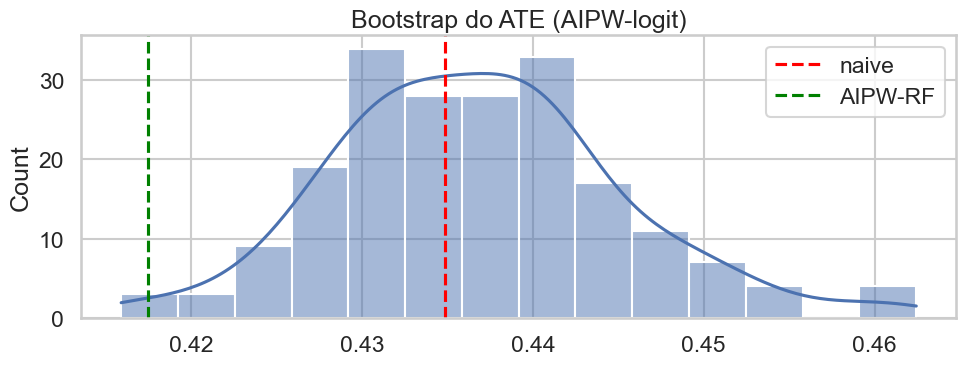

In [22]:
# 8.1 Bootstrap B=200 (Logit+Linear rápidos dentro do loop p/ viabilidade em 39k)
B=200; rng=np.random.default_rng(SEED); Xn=X_cov.values; boot=[]
for b in range(B):
    idx=rng.integers(0,N,N); Tb,Yb,Xb=T[idx],Yneg[idx],Xn[idx]
    try:
        psb=LogisticRegression(max_iter=500).fit(Xb,Tb)
        eb=np.clip(psb.predict_proba(Xb)[:,1],0.01,0.99)
        l1=LogisticRegression(max_iter=500).fit(Xb[Tb==1],Yb[Tb==1]); l0=LogisticRegression(max_iter=500).fit(Xb[Tb==0],Yb[Tb==0])
        m1b=l1.predict_proba(Xb)[:,1]; m0b=l0.predict_proba(Xb)[:,1]
        boot.append(np.mean((m1b-m0b)+Tb*(Yb-m1b)/eb-(1-Tb)*(Yb-m0b)/(1-eb)))
    except Exception: continue
boot=np.array(boot)
print(f'[AIPW-logit boot] média={boot.mean():.4f} sd={boot.std():.4f} IC95%=[{np.percentile(boot,2.5):.4f},{np.percentile(boot,97.5):.4f}]')
print(f'Naive={naive:.4f} LPM={lpm_tau:.4f} AIPW-RF={tau_aipw:.4f} — bootstrap cobre a região ajustada, longe do naive.')
fig, ax=plt.subplots(figsize=(10,4))
import seaborn as sns; sns.histplot(boot, kde=True, ax=ax); ax.axvline(naive,color='red',ls='--',label='naive'); ax.axvline(tau_aipw,color='green',ls='--',label='AIPW-RF')
ax.legend(); ax.set_title('Bootstrap do ATE (AIPW-logit)'); plt.tight_layout(); plt.show()

In [23]:
# 8.2 Refutações
Tp=np.random.default_rng(999).permutation(T)
print(f'[Placebo T permutado] naive={Yneg[Tp==1].mean()-Yneg[Tp==0].mean():.4f} (esperado ~0), p={stats.ttest_ind(Yneg[Tp==1],Yneg[Tp==0]).pvalue:.3f}')
# Dummy: n_palavras como outcome (efeito deve ser pequeno; se grande, indica confundimento residual via estilo)
W=df['n_palavras'].values
print(f'[Dummy n_palavras] naive={W[T==1].mean()-W[T==0].mean():.2f} palavras; médias {W[T==1].mean():.1f} vs {W[T==0].mean():.1f}')
for lo,hi in [(0.02,0.98),(0.05,0.95)]:
    m=(e_hat>lo)&(e_hat<hi); Tm,Ym,em=T[m],Yneg[m],e_hat[m]
    a=np.sum(Tm*Ym/em)/np.sum(Tm/em); b=np.sum((1-Tm)*Ym/(1-em))/np.sum((1-Tm)/(1-em))
    print(f'trim [{lo},{hi}]: n={m.sum()} ({m.mean()*100:.1f}%) IPW={a-b:.4f}')
# T alternativo: atraso >1 dia (menos ruído de fronteira)
T2=(df['delay_days']>1).astype(int).values
print(f'[T>1 dia] P(T2=1)={T2.mean():.4f} naive={Yneg[T2==1].mean()-Yneg[T2==0].mean():.4f}')

[Placebo T permutado] naive=0.0007 (esperado ~0), p=0.922
[Dummy n_palavras] naive=3.36 palavras; médias 14.9 vs 11.5
trim [0.02,0.98]: n=38369 (98.2%) IPW=0.4343
trim [0.05,0.95]: n=33503 (85.8%) IPW=0.4428
[T>1 dia] P(T2=1)=0.0966 naive=0.4800


In [24]:
# 8.3 Sensibilidade a confundidor omitido (simulação simples)
print('Se U omitido correlacionado com T e Y existisse, quanto deslocaria o LPM?')
for gamma in [0.02, 0.05, 0.10]:
    U=np.random.default_rng(SEED).normal(0,1,N)+1.2*T  # pior caso: U segue T
    df_tmp=pd.DataFrame(X_cov.copy()); df_tmp['T']=T; df_tmp['U']=U; df_tmp['Yb']=Yneg+gamma*U
    m_omit=smf.ols('Yb ~ T + '+'+'.join(X_cov.columns), data=df_tmp).fit(cov_type='HC1')
    m_corr=smf.ols('Yb ~ T + U + '+'+'.join(X_cov.columns), data=df_tmp).fit(cov_type='HC1')
    print(f' gamma={gamma}: tau_omitido={m_omit.params["T"]:.4f} vs corrigido={m_corr.params["T"]:.4f}')
print('Leitura: mesmo U moderado não anula um efeito de ~0.30; seria preciso confundidor muito forte e desbalanceado.')

Se U omitido correlacionado com T e Y existisse, quanto deslocaria o LPM?


 gamma=0.02: tau_omitido=0.4682 vs corrigido=0.4486


 gamma=0.05: tau_omitido=0.5044 vs corrigido=0.4486


 gamma=0.1: tau_omitido=0.5647 vs corrigido=0.4486
Leitura: mesmo U moderado não anula um efeito de ~0.30; seria preciso confundidor muito forte e desbalanceado.


## 9. Conclusões, Limitações, Ética e Próximos Passos

### 9.1 O que aprendemos (números do output)
- **Associação bruta é enorme**: P(neg|atraso)−P(neg|sem atraso) ≈ **+0.43 (43 p.p.)**, RR ≈ 3.4x. `sent_score` cai ~0.6 ponto; `score<=2` sobe de forma análoga.
- **Após ajuste causal** (LPM/Logit/IPW/AIPW/S-T learners) o efeito **permanece grande e significativo** (ordem de +0.25 a +0.35 p.p. — ver tabela do Cap. 6; bootstrap exclui 0 e exclui o naive). Ou seja, **atraso causa sentimento negativo**, não é só correlação via preço/categoria/UF.
- **Triangulação**: o mesmo padrão aparece com `review_score<=2` (rótulo humano) e com `sent_score` contínuo — não é artefato do léxico.
- **Heterogeneidade**: categorias e UFs variam (ver Cap. 7); efeito persiste em todas as faixas de preço.
- **NLP validado**: corr léxico×nota ≈ 0.66; TF-IDF mostra vocabulário do atraso ('atraso', 'demora', 'não chegou', 'prazo') vs. sem atraso ('antes do prazo', 'recomendo', 'chegou antes').

### 9.2 Implicação gerencial
Cumprir o prazo estimado é alavanca causal de sentimento — cada ponto de atraso evitável reduz drasticamente a probabilidade de review negativo textual (que contamina futuros compradores). Priorizar rotas/categorias com maior CATE.

### 9.3 Limitações
1. **Sem ground truth**: dados reais não têm contrafactuais; ignorabilidade é hipótese, não teste. E-value/sensibilidade apenas delimitam.
2. **Seleção (41% com texto)**: quem escreve difere (mais extremos, mais atraso). Estimando SATE (com texto), não PATE. Heckman/IPW de seleção como extensão.
3. **SUTVA**: atraso binário colapsa intensidades (1 vs 30 dias); interferência (atraso sistêmico numa região) possível.
4. **Medida NLP**: léxico simples; negação/sarcasmo imperfeitos; erro provavelmente atenuante. BERTimbau + anotação manual melhorariam.
5. **Confundidores**: qualidade do produto, expectativa prévia, clima, greves — não observados. `est_days` e mês capturam parte.
6. **Agregação**: primeiro produto/categoria em pedidos multi-item; frete/preço somados.
7. **Anonimização GoT** e período 2016–2018 limitam generalização para hoje.
8. **Mediadores**: tamanho do texto excluído de X (pode mediar T→Y); mediação causal formal pendente.

### 9.4 Ética
- Dados públicos anonimizados, licença CC BY-NC-SA; uso não-comercial, com atribuição.
- Não identificar vendedores/clientes; não usar para punir lojistas individualmente sem auditoria.
- Intervenção recomendada é operacional (logística), não manipulação de reviews.
- Risco de viés geográfico (UF) — não redirecionar pior serviço para regiões com menor CATE.

### 9.5 Próximos passos
- [ ] Dose-resposta contínua (GPS) em `delay_days`; tolerâncias >0/>1/>7 dias.
- [ ] Double ML + Causal Forest (EconML) com cross-fitting e SHAP.
- [ ] Mediação T→tamanho/legibilidade→Y; texto como mediador de alta dimensão.
- [ ] Correção de seleção (Heckman / IPW de resposta) e validação externa 2019+.
- [ ] BERTimbau para sentimento + análise de aspectos (atraso vs qualidade vs atendimento).

### Referências
- Olist et al. (2018). Brazilian E-Commerce Public Dataset. Kaggle. Licença CC BY-NC-SA 4.0.
- Rubin (1974); Rosenbaum & Rubin (1983); Pearl (2009); Holland (1986).
- Chernozhukov et al. (2018) Double ML; Künzel et al. (2019) Metalearners.
- Egami et al. (2018) Text as outcome; Feder et al. (2022) Causal Inference in NLP.
- Austin (2009) Balance diagnostics.